In [2]:
import sys
print(sys.executable)

/home/adriano/doc/projects/data_science/data_science_temporal_series/.venv/bin/python


In [7]:
import os
print(os.getcwd())

/home/adriano/doc/projects/data_science/data_science_temporal_series


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('data/raw/influenza_parana_semanal.csv', parse_dates=['semana'])
df = df.set_index('semana')

print(df.describe())

            casos
count   57.000000
mean    48.192982
std     38.315625
min      1.000000
25%      9.000000
50%     44.000000
75%     86.000000
max    136.000000


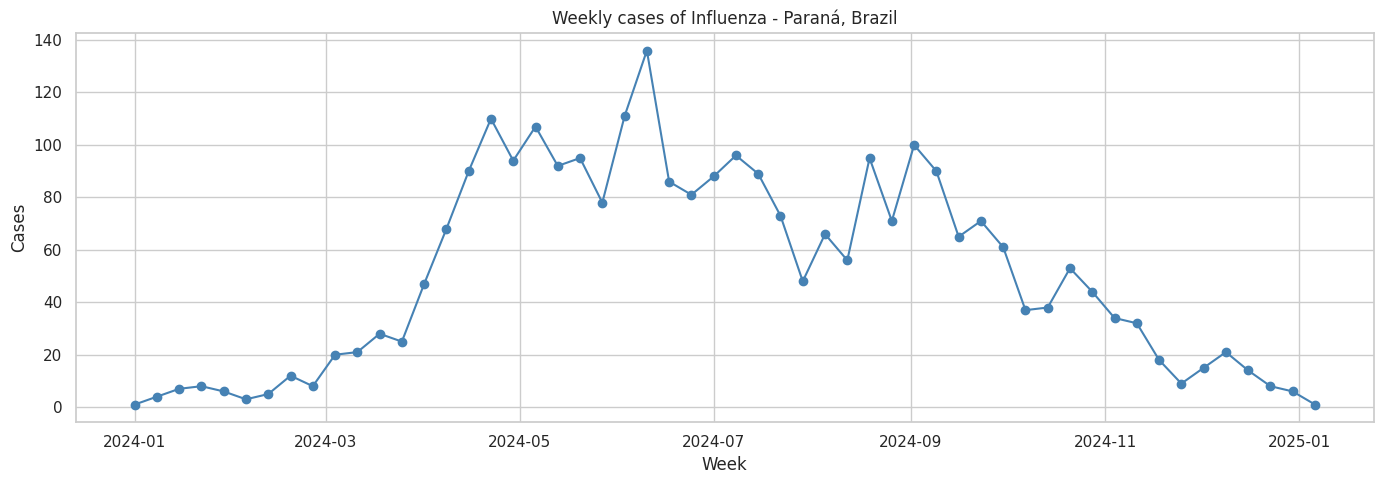

In [15]:
df_plot = df.loc['2024-01-01':'2025-01-31']

plt.figure(figsize=(14, 5))
plt.plot(df_plot.index, df_plot['casos'], marker='o', color='steelblue')
plt.title('Weekly cases of Influenza - Paraná, Brazil')
plt.xlabel('Week')
plt.ylabel('Cases')
plt.tight_layout()
plt.savefig('temporal_series.png', dpi=150)
plt.show()

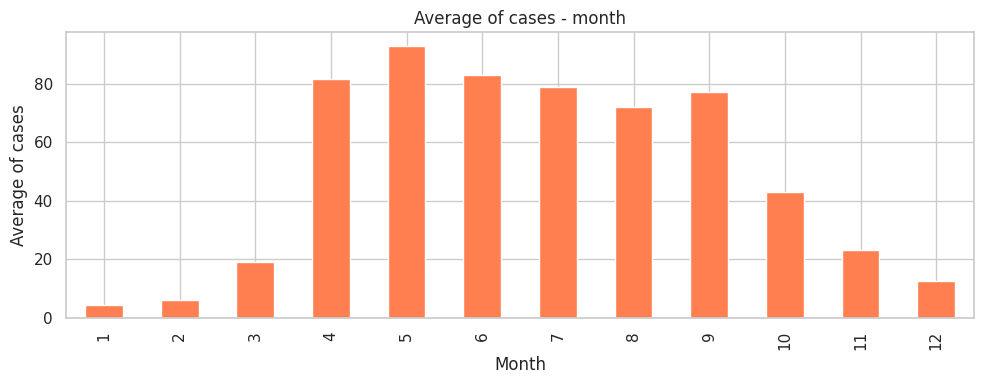

In [17]:
df['mes'] = df.index.month
sazonalidade = df.groupby('mes')['casos'].mean()

plt.figure(figsize=(10, 4))
sazonalidade.plot(kind='bar', color='coral')
plt.title('Average of cases - month')
plt.xlabel('Month')
plt.ylabel('Average of cases')
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()